In [ ]:
import pandas as pd
import sqlite3
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
df1 = pd.read_csv("test1.csv", sep = "\t", on_bad_lines= "warn")
df2 = pd.read_csv("test2.csv",  sep = "\t", on_bad_lines= "warn")
conn_in = sqlite3.connect('test3.db')
df3 = pd.read_sql("SELECT * FROM vacancies", conn_in)

In [ ]:
total_df = pd.concat([df1, df2, df3], ignore_index = True)

In [ ]:
conn_out = sqlite3.connect('total_database.db')
total_df.to_sql(name = 'total_database', con = conn_out, if_exists = 'replace')

2000

In [ ]:
def mean_exp(r):
  exp = r['опыт']
  if pd.isna(exp):
    return None
  if exp == "более 6 лет":
    return 6
  elif exp == '3–6 лет':
    return 4.5
  elif exp == '1–3 года':
    return 2
  else:
    return 0

In [ ]:
total_df['exp'] = total_df.apply(mean_exp, axis = 1)

In [ ]:
tax_by_location = {
    'Москва, Белорусская, Белорусская, Белорусская': 0.13,
    'Бишкек': 0.10,
    'Казань': 0.13,
    'Алматы': 0.10,
    'Москва': 0.13,
    'Москва, Алексеевская': 0.13,
    'Санкт-Петербург': 0.13,
    'Тверь': 0.13,
    'Тюмень': 0.13,
    'Санкт-Петербург, Пушкинская': 0.13,
    'Красноярск': 0.13,
    'Москва, Румянцево, Теплый Стан, Тропарево': 0.13,
    'Ташкент': 0.12,
    'Москва, Выставочная': 0.13,
    'Пермь': 0.13,
    'Сочи': 0.13,
    'Москва, Ленинский проспект': 0.13,
    'Екатеринбург': 0.13,
    'Астана': 0.10,
    'Санкт-Петербург, Чернышевская': 0.13,
    'Нижний Новгород': 0.13,
    'Калуга': 0.13,
    'Томск': 0.13,
    'Новосибирск': 0.13,
    'Москва, Улица 1905 года': 0.13,
    'Воронеж': 0.13,
    'Тбилиси': 0.20,
    'Омск': 0.13,
    'Омск, улица Петра Некрасова, 3': 0.13,
    'Курган': 0.13,
    'Краснодар': 0.13,
    'Чебаркуль': 0.13,
    'Ростов-на-Дону': 0.13,
    'Батуми': 0.20,
    'Турция': 0.15,
    'Москва, Калужская': 0.13,
    'Оренбург': 0.13,
    'ОАЭ': 0.00,
    'Самара': 0.13,
    'Москва, Новокузнецкая, Озерковская набережная, 2/1': 0.13,
    'Санкт-Петербург, Автово, Ленинский проспект, Проспект Ветеранов': 0.13,
    'Баку': 0.14,
    'Москва, Улица Академика Янгеля': 0.13,
    'Пенза': 0.13,
    'США': 0.25,
    'Санкт-Петербург, Чёрная речка': 0.13,
    'Москва, Семеновская': 0.13,
    'Санкт-Петербург, Владимирская, Достоевская': 0.13,
    'Петропавловск-Камчатский': 0.13,
    'Москва, Локомотив, Черкизовская': 0.13,
    'Таганрог': 0.13,
    'Москва, Бауманская': 0.13,
    'Киров (Кировская область)': 0.13,
    'Москва, Динамо': 0.13,
    'Волгоград': 0.13,
    'Талдыкорган': 0.10,
    'Ессентуки': 0.13,
    'Тула': 0.13,
    'Миасс': 0.13,
    'Караганда': 0.10,
    'Уфа': 0.13,
    'Ярославль': 0.13,
    'Сербия': 0.10,
    'Владивосток': 0.13,
    'Королев': 0.13,
    'Горно-Алтайск': 0.13,
    'Минск': 0.13,
    'Кипр': 0.20,
    'Москва, Кузнецкий мост': 0.13,
    'Казань, Площадь Тукая': 0.13,
    'Иннополис': 0.13,
    'Нижний Тагил': 0.13,
    'Армения': 0.21,
    'Москва, Перово': 0.13,
    'Саратов': 0.13,
    'Орел': 0.13,
    'Ейск': 0.13,
    'Сарапул': 0.13,
    'Химки': 0.13,
    'Польша': 0.17,
    'Усть-Каменогорск': 0.10,
    'Москва, Юго-Западная': 0.13,
    'Тольятти': 0.13,
    'Шахты': 0.13,
    'Рязань': 0.13,
    'Липецк': 0.13,
    'Москва, Шоссе Энтузиастов': 0.13,
    'Санкт-Петербург, Лесная, Петроградская, Чёрная речка': 0.13,
    'Зеленоград': 0.13,
    'Иркутск': 0.13,
    'Магнитогорск': 0.13,
    'Чебоксары': 0.13,
    'Москва, Трубная, Цветной бульвар': 0.13,
    '': 0.0,
    'Ижевск': 0.13,
    'Курчатов (Казахстан)': 0.10,
    'Челябинск': 0.13,
    'Брянск': 0.13,
    'Альметьевск': 0.13,
    'Симферополь': 0.13,
    'Калининград': 0.13,
    'Москва, Парк культуры': 0.13,
    'Казань, Авиастроительная , Северный вокзал': 0.13,
    'Эстония': 0.20,
    'Новочеркасск': 0.13,
    'Гомель': 0.13,
    'Москва, Новослободская': 0.13,
    'Сертолово': 0.13,
    'Санкт-Петербург, Гражданский проспект': 0.13,
    'Санкт-Петербург, Московские ворота, Электросила': 0.13,
    'Москва, Каширская, Каширская, Коломенская': 0.13,
    'Верхняя Пышма': 0.13,
    'Сергиев Посад': 0.13,
    'Ульяновск': 0.13,
    'Саранск': 0.13,
    'Муром': 0.13,
    'Минск, Молодежная': 0.13,
    'Кострома': 0.13,
    'Алматы, Байконур, Театр имени Ауэзова': 0.10,
    'Набережные Челны': 0.13,
    'Москва, Свиблово': 0.13,
    'Санкт-Петербург, Площадь Александра Невского 1, Площадь Александра Невского 2': 0.13,
    'Санкт-Петербург, Автово, Кировский завод, Ленинский проспект': 0.13,
    'Астрахань': 0.13,
    'Якутск': 0.13,
    'Ставрополь': 0.13,
    'Санкт-Петербург, Площадь Мужества, Политехническая': 0.13,
    'Иваново (Ивановская область)': 0.13,
    'Санкт-Петербург, Садовая, Сенная площадь, Спасская': 0.13,
    'Старый Оскол': 0.13
}


In [ ]:
def mean_salary(r):
  sal = r['зп']
  region = r['регион']
  if pd.isna(sal):
    return None
  sal = str(sal)
  num = re.findall(r'\d+(?:[ \xa0]\d+)*', sal)
  num = [int(n.replace(' ', '').replace('\xa0','')) for n in num]
  if len(num) == 2:
    mean_sal = float(sum(num)) / 2
  elif len(num) == 1:
    mean_sal = float(sum(num))
  else:
    return None

  sal = sal.lower()
  if 'до вычета налогов' in sal and not(pd.isna(region)):
    mean_sal_tax =  mean_sal * (1 - tax_by_location[region])
  else:
    mean_sal_tax = mean_sal

  if 'usd' in sal:
    return mean_sal_tax * 81.50
  if 'eur' in sal:
    return mean_sal_tax * 94.64
  if 'kzt' in sal:
    return mean_sal_tax * 0.1513
  if 'бел' in sal:
    return mean_sal_tax * 23.93
  if 'сум' in sal:
    return mean_sal_tax * 0.00675
  return mean_sal_tax

In [ ]:
total_df['sal'] = total_df.apply(mean_salary, axis = 1)

In [ ]:
total_df.head(10)

,id,название,опыт,занятость,зп,работодатель,регион,описание,навыки,опыт',exp,sal,город,is_senior
0,71716792,Senior/Lead Frontend Developer at JoomPro (to ...,более 6 лет,"Полная занятость, гибкий график",от 380 000 руб. до вычета налогов,Joom,"Москва, Белорусская, Белорусская, Белорусская",JoomPro — платформа для кросс-бордерной оптово...,"['React.js', 'JavaScript', 'HTML', 'Teamleading']",NaN,6.0,330600.0,Москва,Seniors
1,77081730,Разработчик 1С,3–6 лет,"Полная занятость, удаленная работа",з/п не указана,SCARLETT,NaN,В сопроводительном письме обязательно указать ...,"['Обновление конфигурации 1С', '1С программиро...",NaN,4.5,NaN,None,Others
2,77611219,Flutter разработчик,1–3 года,"Полная занятость, удаленная работа",от 110 000 руб. на руки,ИП Кравченко Е.А.,NaN,В проект Flyvi.io (графический онлайн редактор...,"['ООП', 'Ajax', 'Git', 'HTML', 'JavaScript', '...",NaN,2.0,110000.0,None,Others
3,55312440,Программист ПО,1–3 года,"Полная занятость, удаленная работа",от 100 000 до 180 000 руб. до вычета налогов,1С:Апрель Софт,NaN,"Компания ""1C:Апрель СОФТ"" приглашает на ваканс...",[],NaN,2.0,140000.0,None,Others
4,77538137,Разработчик 1C,3–6 лет,"Полная занятость, полный день",от 130 000 руб. на руки,ООО ЛИГРЕС,Бишкек,"«Legal Resourсes» - ИТ компания, которая заним...","['1С: Документооборот', '1С программирование',...",NaN,4.5,130000.0,Бишкек,Others
5,77068589,Js-программист,1–3 года,"Полная занятость, полный день",от 120 000 до 180 000 руб. до вычета налогов,ЗАО НОРСИ-ТРАНС,NaN,Обязанности: Разработка комплексных SPA-прил...,"['HTML', 'API', 'JavaScript', 'JS']",NaN,2.0,150000.0,None,Others
6,77717090,Middle Frontend Разработчик,1–3 года,"Полная занятость, полный день",от 60 000 до 90 000 руб. на руки,Digital Partners Global,NaN,"Привет! Мы - команда классных специалистов, за...","['JavaScript', 'ООП', 'svelte', 'TypeScript', ...",NaN,2.0,75000.0,None,Others
7,71499934,Junior разработчик (поисковая выдача),1–3 года,"Частичная занятость, удаленная работа",до 65 000 руб. на руки,Яндекс,Казань,"Мы в Яндексе очень хотим, чтобы наш Поиск выда...",[],NaN,2.0,65000.0,Казань,Others
8,76937998,"Программист C#, SQL",1–3 года,"Полная занятость, полный день",з/п не указана,ООО ПАГ,NaN,Process Automation Group (PAG) - компания по в...,"['C#', 'TypeScript', '.Net', '.NET Core', 'MSM...",NaN,2.0,NaN,None,Others
9,77097256,Full Stack Developer,3–6 лет,"Полная занятость, удаленная работа",от 2 400 до 4 800 USD до вычета налогов,Actsoft,NaN,Responsibilities: A software engineer is a s...,"['Git', 'C#', 'Azure', '.NET Core', 'ASP.NET',...",NaN,4.5,293400.0,None,Others


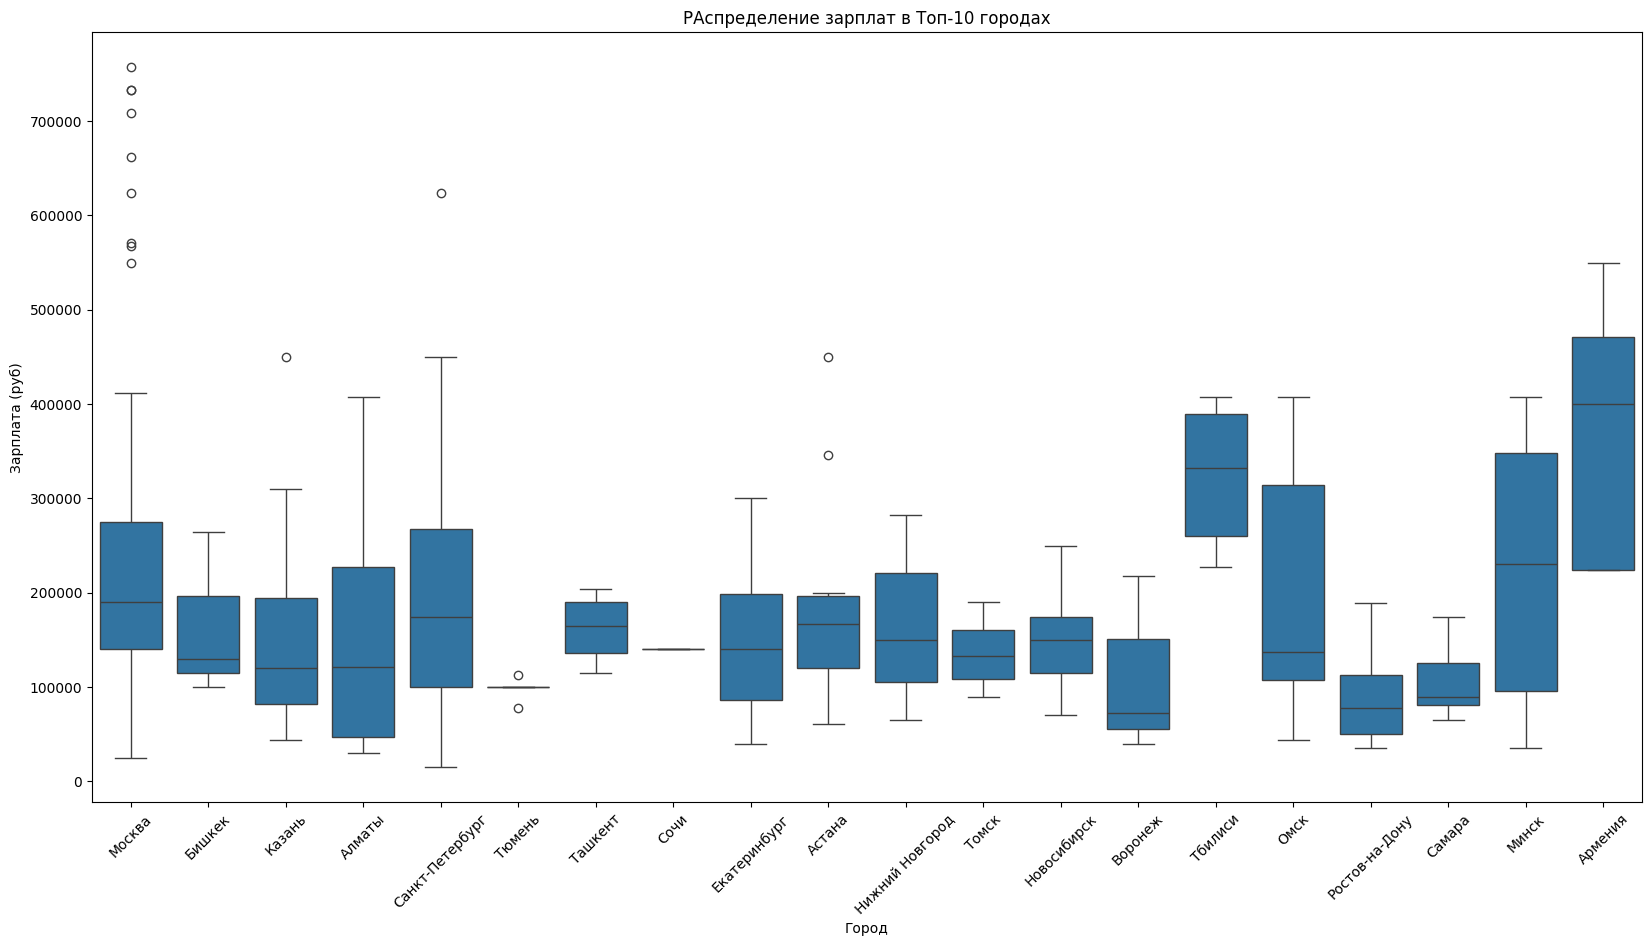

In [ ]:
total_df['город'] = total_df['регион'].fillna('').apply(lambda x: x.split(',')[0].strip() if x else None)
top_cities = total_df['город'].value_counts().nlargest(20).index

plt.figure(figsize=(20,10))
sns.boxplot(x='город', y='sal', data=total_df[total_df['город'].isin(top_cities)])
plt.xticks(rotation=45)
plt.title('РАспределение зарплат в Топ-10 городах')
plt.ylabel('Зарплата (руб)')
plt.xlabel('Город')
plt.show()

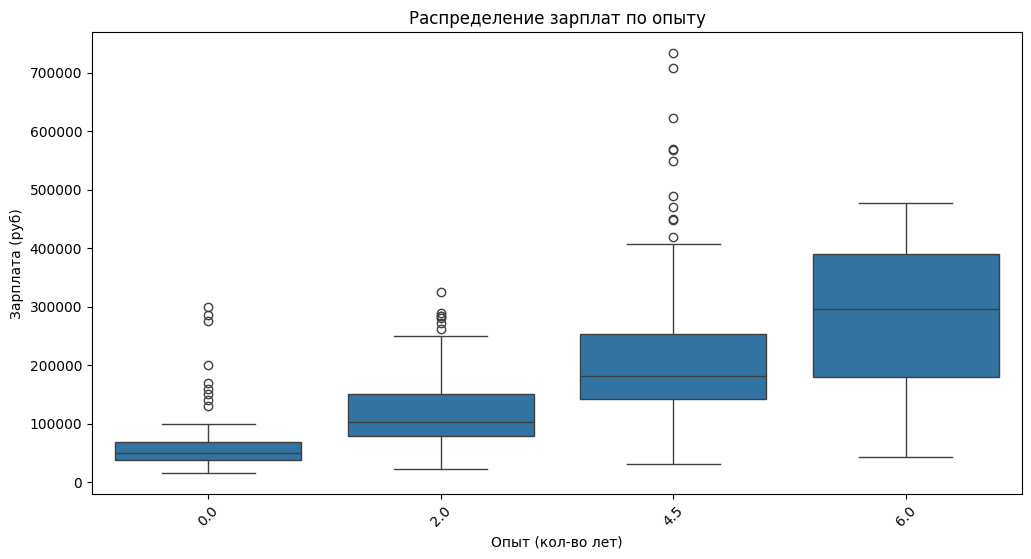

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x='exp', y='sal', data = total_df)
plt.xticks(rotation=45)
plt.title('Распределение зарплат по опыту')
plt.ylabel('Зарплата (руб)')
plt.xlabel('Опыт (кол-во лет)')
plt.show()

In [ ]:
groups = [group["sal"].dropna() for name, group in total_df.groupby("exp")]

f_stat, p_value = stats.f_oneway(*groups)

print(f"F-статистика: {f_stat:.3f}, p-value: {p_value:.5f}")

F-статистика: 109.780, p-value: 0.00000


Различия статистически значимы. Зарплата зависит от опыта.

In [ ]:
contingency_table = pd.crosstab(total_df['город'], total_df['exp'])

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi² = {chi2:.3f}, p-value = {p:.5f}, Степени свободы = {dof}")


Chi² = 310.372, p-value = 0.00000, Степени свободы = 198


Занятость зависит от региона.

In [ ]:
def senior_vs_others(r):
  name = r['название']
  if pd.isna(name):
    return 'Others'
  name = name.lower()
  if any(word in name for word in ['ведущий', 'старший', 'senior']):
    return 'Seniors'
  else:
    return 'Others'

In [ ]:
total_df['is_senior'] = total_df.apply(senior_vs_others, axis = 1)

In [ ]:
total_df.head(10)

,id,название,опыт,занятость,зп,работодатель,регион,описание,навыки,опыт',exp,sal,город,is_senior
0,71716792,Senior/Lead Frontend Developer at JoomPro (to ...,более 6 лет,"Полная занятость, гибкий график",от 380 000 руб. до вычета налогов,Joom,"Москва, Белорусская, Белорусская, Белорусская",JoomPro — платформа для кросс-бордерной оптово...,"['React.js', 'JavaScript', 'HTML', 'Teamleading']",NaN,6.0,330600.0,Москва,Seniors
1,77081730,Разработчик 1С,3–6 лет,"Полная занятость, удаленная работа",з/п не указана,SCARLETT,NaN,В сопроводительном письме обязательно указать ...,"['Обновление конфигурации 1С', '1С программиро...",NaN,4.5,NaN,None,Others
2,77611219,Flutter разработчик,1–3 года,"Полная занятость, удаленная работа",от 110 000 руб. на руки,ИП Кравченко Е.А.,NaN,В проект Flyvi.io (графический онлайн редактор...,"['ООП', 'Ajax', 'Git', 'HTML', 'JavaScript', '...",NaN,2.0,110000.0,None,Others
3,55312440,Программист ПО,1–3 года,"Полная занятость, удаленная работа",от 100 000 до 180 000 руб. до вычета налогов,1С:Апрель Софт,NaN,"Компания ""1C:Апрель СОФТ"" приглашает на ваканс...",[],NaN,2.0,140000.0,None,Others
4,77538137,Разработчик 1C,3–6 лет,"Полная занятость, полный день",от 130 000 руб. на руки,ООО ЛИГРЕС,Бишкек,"«Legal Resourсes» - ИТ компания, которая заним...","['1С: Документооборот', '1С программирование',...",NaN,4.5,130000.0,Бишкек,Others
5,77068589,Js-программист,1–3 года,"Полная занятость, полный день",от 120 000 до 180 000 руб. до вычета налогов,ЗАО НОРСИ-ТРАНС,NaN,Обязанности: Разработка комплексных SPA-прил...,"['HTML', 'API', 'JavaScript', 'JS']",NaN,2.0,150000.0,None,Others
6,77717090,Middle Frontend Разработчик,1–3 года,"Полная занятость, полный день",от 60 000 до 90 000 руб. на руки,Digital Partners Global,NaN,"Привет! Мы - команда классных специалистов, за...","['JavaScript', 'ООП', 'svelte', 'TypeScript', ...",NaN,2.0,75000.0,None,Others
7,71499934,Junior разработчик (поисковая выдача),1–3 года,"Частичная занятость, удаленная работа",до 65 000 руб. на руки,Яндекс,Казань,"Мы в Яндексе очень хотим, чтобы наш Поиск выда...",[],NaN,2.0,65000.0,Казань,Others
8,76937998,"Программист C#, SQL",1–3 года,"Полная занятость, полный день",з/п не указана,ООО ПАГ,NaN,Process Automation Group (PAG) - компания по в...,"['C#', 'TypeScript', '.Net', '.NET Core', 'MSM...",NaN,2.0,NaN,None,Others
9,77097256,Full Stack Developer,3–6 лет,"Полная занятость, удаленная работа",от 2 400 до 4 800 USD до вычета налогов,Actsoft,NaN,Responsibilities: A software engineer is a s...,"['Git', 'C#', 'Azure', '.NET Core', 'ASP.NET',...",NaN,4.5,293400.0,None,Others


In [ ]:
seniors = total_df.loc[total_df['is_senior'] == 'Seniors', 'sal'].dropna()
others = total_df.loc[total_df['is_senior'] == 'Others', 'sal'].dropna()

t_stat, p_value = stats.ttest_ind(seniors, others, equal_var=False)

print(f"T-статистика: {t_stat:.3f}, p-value: {p_value:.5f}")

T-статистика: 17.004, p-value: 0.00000


Зарплаты различаются значимо

In [ ]:
n = 1000000

np.random.seed(42)

df = pd.DataFrame({
    'пол': np.random.choice(['мужской', 'женский'], size=n),
    'возраст': np.random.normal(35, 10, n).astype(int),
    'доход': np.random.normal(80000, 25000, n).astype(int),
    'профессия': np.random.choice(['аналитик', 'программист', 'менеджер', 'дизайнер'], size=n)
})

In [ ]:
df.info(memory_usage='deep')
df.memory_usage(deep=True).sum()/1024/1024

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   пол        1000000 non-null  object
 1   возраст    1000000 non-null  int64 
 2   доход      1000000 non-null  int64 
 3   профессия  1000000 non-null  object
dtypes: int64(2), object(2)
memory usage: 171.2 MB


np.float64(171.1822166442871)

In [ ]:
%%timeit
df.to_csv('data.csv', index=False)

2 s ± 296 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%%timeit
df_loaded = pd.read_csv('data.csv')

602 ms ± 5.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%%timeit
agg = {
    'возраст': 'mean',
    'доход': 'max',
    'пол': lambda x: x.mode()[0],
    'профессия': lambda x: x.value_counts().idxmin()
}

result = df.agg(agg)

190 ms ± 34.1 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
